# Heatmap Respons Yield Padi Selama Episode El Niño Historis

Notebook ini menjawab satu pertanyaan: **ketika El Niño terjadi pada masa lalu, seberapa jauh yield padi setiap negara ASEAN bergerak dari tren jangka panjangnya?**

Metode utama:

1. Membersihkan data RONI dan yield padi.
2. Mendeteksi episode El Niño dari RONI ≥ +0,5°C selama sedikitnya lima musim tiga bulanan berturut-turut.
3. Mengestimasi expected yield dengan tren kuadratik per negara pada 1990 sampai tahun lengkap terbaru.
4. Menghitung yield anomaly dalam persen.
5. Merata-ratakan anomaly pada seluruh tahun berlabel NOAA yang dilewati episode.
6. Membuat heatmap dengan skala warna simetris terhadap nol.
7. Memeriksa sensitivitas terhadap tren linear, peak year, dan tahun setelah peak.

**Input:** `RONI_3_Months.csv` dan `rice-yields(1).csv`  
**Negara:** Cambodia, Indonesia, Lao PDR, Malaysia, Myanmar, Philippines, Thailand, dan Viet Nam.

Sumber konsep dan definisi: [NOAA CPC RONI](https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/) dan [FAOSTAT Crops and Livestock Products](https://www.fao.org/faostat/).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font_scale=0.95)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SEASONS = [
    "DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ",
    "JJA", "JAS", "ASO", "SON", "OND", "NDJ"
]
SEASON_ORDER = {season: order for order, season in enumerate(SEASONS)}

TARGET_COUNTRIES = [
    "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Myanmar", "Philippines", "Thailand", "Viet Nam"
]
COUNTRY_NAME_MAP = {"Laos": "Lao PDR", "Vietnam": "Viet Nam"}

ANALYSIS_START = 1990
RONI_THRESHOLD = 0.5
MIN_CONSECUTIVE_SEASONS = 5


def resolve_input(filename):
    # Find an input next to the notebook or in a nearby upload folder.
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / "upload" / filename,
        Path.cwd().parent / "upload" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"{filename} tidak ditemukan. Lokasi yang diperiksa:\n{searched}")


RONI_PATH = resolve_input("RONI_3_Months.csv")
YIELD_PATH = resolve_input("rice-yields.csv")

print("RONI source :", RONI_PATH)
print("Yield source:", YIELD_PATH)


RONI source : C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\RONI_3_Months.csv
Yield source: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\rice-yields.csv


## 1. Memuat dan memeriksa data sumber

Pemeriksaan awal memastikan nama kolom, unit yield, jumlah baris, dan bentuk tabel RONI sesuai dengan yang dibutuhkan. File sumber tidak diubah.


In [2]:
roni_raw = pd.read_csv(RONI_PATH, dtype=str)
yield_raw = pd.read_csv(YIELD_PATH)

print(f"RONI raw: {roni_raw.shape[0]} baris × {roni_raw.shape[1]} kolom")
print(f"Yield raw: {yield_raw.shape[0]} baris × {yield_raw.shape[1]} kolom")
print("\nKolom RONI:", list(roni_raw.columns))
print("Kolom yield:", list(yield_raw.columns))

display(roni_raw.head(5))
display(yield_raw.head(5))

required_roni = {"Year", *SEASONS}
required_yield = {"Entity", "Year", "Rice - Yield (tonnes per hectare)"}
assert required_roni.issubset(roni_raw.columns), "Kolom RONI tidak lengkap"
assert required_yield.issubset(yield_raw.columns), "Kolom yield tidak lengkap"


RONI raw: 84 baris × 13 kolom
Yield raw: 640 baris × 4 kolom

Kolom RONI: ['Year', 'DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']
Kolom yield: ['Entity', 'Code', 'Year', 'Rice - Yield (tonnes per hectare)']


,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950,-1.2,-1.1,-1.0,-1.0,-1.0,-0.7,-0.4,-0.3,-0.3,-0.4,-0.4,-0.5
1,1951,-0.3,0.1,0.5,0.6,0.6,0.7,0.8,1.0,1.0,1.0,0.9,0.7
2,1952,0.7,0.3,0.5,0.2,0.0,-0.4,-0.4,-0.1,0.1,0.0,-0.1,0.1
3,1953,0.4,0.7,0.7,0.7,0.9,0.8,0.7,0.7,0.7,0.8,0.6,0.7
4,1954,0.6,0.6,0.3,0.0,-0.2,-0.2,-0.4,-0.6,-0.5,-0.3,-0.1,-0.2


,Entity,Code,Year,Rice - Yield (tonnes per hectare)
0,Brunei,BRN,1961,1.7306
1,Brunei,BRN,1962,1.8527
2,Brunei,BRN,1963,1.3711
3,Brunei,BRN,1964,1.3235
4,Brunei,BRN,1965,1.1737


## 2. Membersihkan dan membatasi periode analisis

- Baris header berulang di dalam CSV RONI dibuang dengan mengubah `Year` menjadi numerik.
- Nilai RONI yang belum tersedia dibuang setelah tabel diubah ke format panjang.
- Nama `Laos` dan `Vietnam` diselaraskan menjadi `Lao PDR` dan `Viet Nam`.
- Brunei dan East Timor tidak masuk heatmap.
- Tahun akhir dipilih sebagai tahun terbaru yang memiliki data yield untuk semua delapan negara.

**Catatan kualitas data:** file yield yang diberikan tidak memiliki kolom `Flag`. Karena itu, notebook ini tidak dapat membedakan data resmi, estimasi FAO, dan hasil imputasi.


In [3]:
# RONI: buang header berulang dan ubah menjadi tabel Year, Season, RONI.
roni_numeric_year = pd.to_numeric(roni_raw["Year"], errors="coerce")
repeated_header_rows = int(roni_numeric_year.isna().sum())

roni_wide = roni_raw.loc[roni_numeric_year.notna(), ["Year", *SEASONS]].copy()
roni_wide["Year"] = pd.to_numeric(roni_wide["Year"]).astype(int)

roni_long = roni_wide.melt(
    id_vars="Year",
    value_vars=SEASONS,
    var_name="Season",
    value_name="RONI"
)
roni_long["RONI"] = pd.to_numeric(roni_long["RONI"], errors="coerce")
missing_roni_values = int(roni_long["RONI"].isna().sum())
roni_long["Season_Order"] = roni_long["Season"].map(SEASON_ORDER)
roni_long = (
    roni_long.dropna(subset=["RONI"])
    .sort_values(["Year", "Season_Order"])
    .reset_index(drop=True)
)

# Yield: samakan nama kolom, negara, unit, dan tipe data.
yield_data = yield_raw.rename(
    columns={
        "Entity": "Country",
        "Rice - Yield (tonnes per hectare)": "Yield"
    }
).copy()
yield_data["Country"] = yield_data["Country"].replace(COUNTRY_NAME_MAP)
yield_data["Year"] = pd.to_numeric(yield_data["Year"], errors="coerce")
yield_data["Yield"] = pd.to_numeric(yield_data["Yield"], errors="coerce")
yield_data = yield_data[yield_data["Country"].isin(TARGET_COUNTRIES)].copy()

# Tahun lengkap berarti semua delapan negara memiliki satu nilai yield nonmissing.
complete_year_counts = (
    yield_data.dropna(subset=["Year", "Yield"])
    .groupby("Year")["Country"]
    .nunique()
)
complete_years = complete_year_counts[complete_year_counts.eq(len(TARGET_COUNTRIES))].index.astype(int)
analysis_end = int(max(year for year in complete_years if year >= ANALYSIS_START))

yield_data = yield_data[
    yield_data["Year"].between(ANALYSIS_START, analysis_end)
].copy()
yield_data["Year"] = yield_data["Year"].astype(int)
yield_data = yield_data.sort_values(["Country", "Year"]).reset_index(drop=True)

duplicate_country_years = int(yield_data.duplicated(["Country", "Year"]).sum())
country_qc = (
    yield_data.groupby("Country")
    .agg(
        First_Year=("Year", "min"),
        Last_Year=("Year", "max"),
        Observations=("Year", "size"),
        Missing_Yield=("Yield", lambda s: int(s.isna().sum())),
        Min_Yield_t_ha=("Yield", "min"),
        Max_Yield_t_ha=("Yield", "max"),
    )
    .reindex(TARGET_COUNTRIES)
)

print(f"Header berulang yang dibuang dari RONI: {repeated_header_rows}")
print(f"Nilai RONI kosong yang dibuang: {missing_roni_values}")
print(f"Periode yield bersama: {ANALYSIS_START}–{analysis_end}")
print(f"Duplikat country-year: {duplicate_country_years}")
print("Flag tersedia:", "Flag" in yield_raw.columns)
display(country_qc.round(3))

assert duplicate_country_years == 0
assert country_qc["Missing_Yield"].sum() == 0
assert country_qc["Observations"].nunique() == 1


Header berulang yang dibuang dari RONI: 7
Nilai RONI kosong yang dibuang: 6
Periode yield bersama: 1990–2024
Duplikat country-year: 0
Flag tersedia: False


,First_Year,Last_Year,Observations,Missing_Yield,Min_Yield_t_ha,Max_Yield_t_ha
Country,,,,,,
Cambodia,1990,2024,35,0,1.307,3.644
Indonesia,1990,2024,35,0,4.197,5.359
Lao PDR,1990,2024,35,0,2.198,4.263
Malaysia,1990,2024,35,0,2.769,4.629
Myanmar,1990,2024,35,0,2.886,4.066
Philippines,1990,2024,35,0,2.699,4.165
Thailand,1990,2024,35,0,1.956,3.214
Viet Nam,1990,2024,35,0,3.113,6.152


## 3. Mendeteksi episode El Niño dari RONI

Setiap musim dengan RONI ≥ +0,5°C ditandai sebagai musim hangat. Musim hangat yang berurutan dikelompokkan menjadi satu run. Hanya run dengan sedikitnya lima musim yang dipertahankan sebagai episode El Niño.

`Event_Years` menggunakan label tahun pada tabel NOAA. Ini konsisten dengan struktur contoh, sehingga episode DJF–SON 1993 tetap diperlakukan sebagai episode satu tahun `1993`.


In [4]:
roni_long["Warm_Season"] = roni_long["RONI"].ge(RONI_THRESHOLD)
roni_long["Run_ID"] = roni_long["Warm_Season"].ne(
    roni_long["Warm_Season"].shift(fill_value=False)
).cumsum()

detected_rows = []
for _, run in roni_long.loc[roni_long["Warm_Season"]].groupby("Run_ID", sort=False):
    if len(run) < MIN_CONSECUTIVE_SEASONS:
        continue
    start = run.iloc[0]
    end = run.iloc[-1]
    peak = run.loc[run["RONI"].idxmax()]
    start_year = int(start["Year"])
    end_year = int(end["Year"])
    detected_rows.append(
        {
            "Start_Season": f"{start['Season']} {start_year}",
            "End_Season": f"{end['Season']} {end_year}",
            "Peak_Season": f"{peak['Season']} {int(peak['Year'])}",
            "Start_Year": start_year,
            "End_Year": end_year,
            "Peak_Year": int(peak["Year"]),
            "Peak_RONI": float(peak["RONI"]),
            "Warm_Seasons": int(len(run)),
            "Event_Years": tuple(range(start_year, end_year + 1)),
        }
    )

all_episodes = pd.DataFrame(detected_rows)

available_pairs = set(zip(yield_data["Country"], yield_data["Year"]))


def has_complete_yield(event_years):
    return all(
        (country, year) in available_pairs
        for country in TARGET_COUNTRIES
        for year in event_years
    )


episodes = all_episodes[
    all_episodes["Start_Year"].ge(ANALYSIS_START)
    & all_episodes["End_Year"].le(analysis_end)
].copy()
episodes["Complete_Yield"] = episodes["Event_Years"].map(has_complete_yield)
episodes = episodes.loc[episodes["Complete_Yield"]].reset_index(drop=True)
episodes.insert(0, "Episode_ID", [f"EN_{i:02d}" for i in range(1, len(episodes) + 1)])
episodes["Episode_Label"] = episodes.apply(
    lambda row: str(row["Start_Year"])
    if row["Start_Year"] == row["End_Year"]
    else f"{row['Start_Year']}-{str(row['End_Year'])[-2:]}",
    axis=1,
)

episode_table = episodes[
    [
        "Episode_ID", "Episode_Label", "Start_Season", "End_Season",
        "Peak_Season", "Peak_RONI", "Warm_Seasons", "Event_Years"
    ]
]

print(f"Episode terdeteksi pada seluruh periode RONI: {len(all_episodes)}")
print(f"Episode yang masuk heatmap {ANALYSIS_START}–{analysis_end}: {len(episodes)}")
display(episode_table)

assert episodes["Complete_Yield"].all()
assert episodes["Episode_Label"].is_unique


Episode terdeteksi pada seluruh periode RONI: 25
Episode yang masuk heatmap 1990–2024: 11


,Episode_ID,Episode_Label,Start_Season,End_Season,Peak_Season,Peak_RONI,Warm_Seasons,Event_Years
0,EN_01,1991-92,AMJ 1991,JJA 1992,DJF 1992,2.1,15,"(1991, 1992)"
1,EN_02,1993,DJF 1993,SON 1993,MAM 1993,1.1,10,"(1993,)"
2,EN_03,1994-95,JJA 1994,FMA 1995,NDJ 1994,1.3,9,"(1994, 1995)"
3,EN_04,1997-98,MAM 1997,MAM 1998,OND 1997,2.3,13,"(1997, 1998)"
4,EN_05,2002-03,JJA 2002,JFM 2003,OND 2002,1.3,8,"(2002, 2003)"
5,EN_06,2004-05,JJA 2004,DJF 2005,JAS 2004,0.7,7,"(2004, 2005)"
6,EN_07,2006-07,ASO 2006,DJF 2007,OND 2006,0.9,5,"(2006, 2007)"
7,EN_08,2009-10,ASO 2009,FMA 2010,NDJ 2009,1.5,7,"(2009, 2010)"
8,EN_09,2014-16,OND 2014,MAM 2016,NDJ 2015,2.3,18,"(2014, 2015, 2016)"
9,EN_10,2018-19,SON 2018,MAM 2019,OND 2018,0.8,7,"(2018, 2019)"


## 4. Mengestimasi expected yield

Tren dihitung terpisah untuk setiap negara agar perubahan teknologi, varietas, pupuk, dan irigasi tidak keliru dibaca sebagai dampak El Niño.

Metode utama adalah tren kuadratik:

\[
\widehat{Yield}_{i,t}=\beta_{0,i}+\beta_{1,i}x_t+\beta_{2,i}x_t^2
\]

dengan \(x_t = Year_t - \overline{Year}\). Tahun dipusatkan untuk menjaga stabilitas numerik. Tren linear dihitung pada data yang sama sebagai sensitivity check.


In [5]:
def fit_yield_trends(group):
    group = group.sort_values("Year").copy()
    x = group["Year"].to_numpy(dtype=float)
    y = group["Yield"].to_numpy(dtype=float)
    x_centered = x - x.mean()

    coef_quad = np.polyfit(x_centered, y, deg=2)
    coef_linear = np.polyfit(x_centered, y, deg=1)

    expected_quad = np.polyval(coef_quad, x_centered)
    expected_linear = np.polyval(coef_linear, x_centered)

    group["Expected_Yield_Quadratic"] = expected_quad
    group["Expected_Yield_Linear"] = expected_linear
    group["Yield_Anomaly_Quadratic"] = (y / expected_quad - 1) * 100
    group["Yield_Anomaly_Linear"] = (y / expected_linear - 1) * 100
    return group


yield_parts = [
    fit_yield_trends(group)
    for _, group in yield_data.groupby("Country", sort=False)
]
yield_anomalies = pd.concat(yield_parts, ignore_index=True)


def r_squared(actual, fitted):
    actual = np.asarray(actual)
    fitted = np.asarray(fitted)
    ss_res = np.square(actual - fitted).sum()
    ss_tot = np.square(actual - actual.mean()).sum()
    return 1 - ss_res / ss_tot


trend_qc_rows = []
for country, group in yield_anomalies.groupby("Country"):
    trend_qc_rows.append(
        {
            "Country": country,
            "R2_Quadratic": r_squared(group["Yield"], group["Expected_Yield_Quadratic"]),
            "R2_Linear": r_squared(group["Yield"], group["Expected_Yield_Linear"]),
            "Min_Expected_Quadratic": group["Expected_Yield_Quadratic"].min(),
            "Min_Expected_Linear": group["Expected_Yield_Linear"].min(),
        }
    )

trend_qc = pd.DataFrame(trend_qc_rows).set_index("Country").reindex(TARGET_COUNTRIES)
display(trend_qc.round(3))

assert (trend_qc[["Min_Expected_Quadratic", "Min_Expected_Linear"]] > 0).all().all()


,R2_Quadratic,R2_Linear,Min_Expected_Quadratic,Min_Expected_Linear
Country,,,,
Cambodia,0.974,0.971,1.195,1.282
Indonesia,0.882,0.881,4.189,4.169
Lao PDR,0.940,0.880,2.079,2.403
Malaysia,0.693,0.600,2.680,2.928
Myanmar,0.910,0.788,2.739,3.018
Philippines,0.923,0.918,2.659,2.731
Thailand,0.917,0.678,1.971,2.306
Viet Nam,0.990,0.965,3.007,3.314


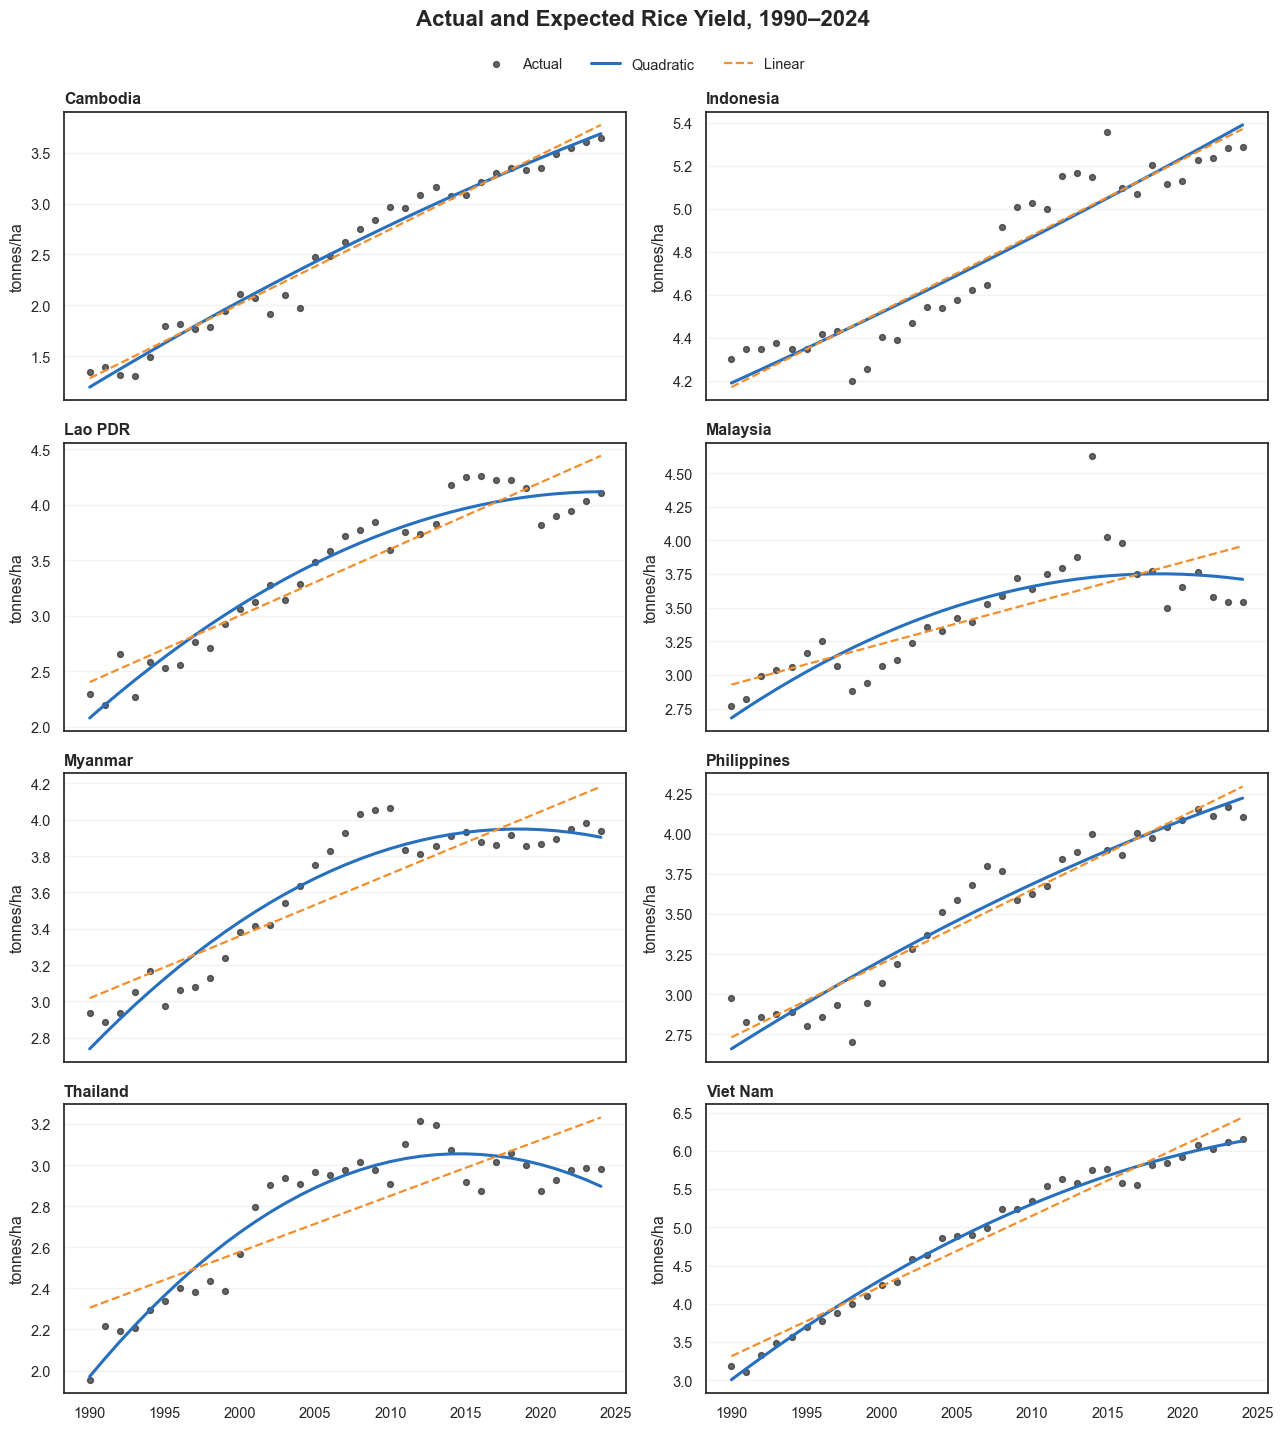

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14), sharex=True)
for ax, country in zip(axes.flat, TARGET_COUNTRIES):
    group = yield_anomalies[yield_anomalies["Country"].eq(country)]
    ax.scatter(group["Year"], group["Yield"], s=18, color="#333333", alpha=0.75, label="Actual")
    ax.plot(group["Year"], group["Expected_Yield_Quadratic"], color="#276FBF", lw=2.2, label="Quadratic")
    ax.plot(group["Year"], group["Expected_Yield_Linear"], color="#F28E2B", lw=1.6, ls="--", label="Linear")
    ax.set_title(country, loc="left", fontweight="bold")
    ax.set_ylabel("tonnes/ha")
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.995))
fig.suptitle(
    f"Actual and Expected Rice Yield, {ANALYSIS_START}–{analysis_end}",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
fig.tight_layout()
plt.show()


## 5. Menghitung yield anomaly

Untuk setiap negara dan tahun:

\[
YieldAnomaly_{i,t}=\left(\frac{ActualYield_{i,t}}{ExpectedYield_{i,t}}-1\right)\times100
\]

Nilai negatif berarti yield berada di bawah tren yang diharapkan. Nilai positif berarti yield berada di atas tren. Nilai ini bukan perubahan dari tahun sebelumnya.


In [7]:
anomaly_preview = yield_anomalies[
    [
        "Country", "Year", "Yield", "Expected_Yield_Quadratic",
        "Yield_Anomaly_Quadratic", "Expected_Yield_Linear",
        "Yield_Anomaly_Linear"
    ]
].copy()

display(anomaly_preview.groupby("Country", sort=False).head(2).round(3))

anomaly_summary = (
    yield_anomalies.groupby("Country")
    .agg(
        Mean_Anomaly=("Yield_Anomaly_Quadratic", "mean"),
        Min_Anomaly=("Yield_Anomaly_Quadratic", "min"),
        Max_Anomaly=("Yield_Anomaly_Quadratic", "max"),
    )
    .reindex(TARGET_COUNTRIES)
)
display(anomaly_summary.round(2))


,Country,Year,Yield,Expected_Yield_Quadratic,Yield_Anomaly_Quadratic,Expected_Yield_Linear,Yield_Anomaly_Linear
0,Cambodia,1990,1.348,1.195,12.760,1.282,5.127
1,Cambodia,1991,1.396,1.284,8.755,1.355,3.020
35,Indonesia,1990,4.302,4.189,2.705,4.169,3.178
36,Indonesia,1991,4.347,4.220,2.986,4.205,3.374
70,Lao PDR,1990,2.294,2.079,10.309,2.403,-4.547
71,Lao PDR,1991,2.198,2.196,0.065,2.463,-10.763
105,Malaysia,1990,2.769,2.680,3.334,2.928,-5.416
106,Malaysia,1991,2.818,2.754,2.312,2.958,-4.749
140,Myanmar,1990,2.935,2.739,7.151,3.018,-2.744
141,Myanmar,1991,2.886,2.823,2.227,3.052,-5.461


,Mean_Anomaly,Min_Anomaly,Max_Anomaly
Country,,,
Cambodia,0.09,-15.90,12.76
Indonesia,0.00,-5.68,6.13
Lao PDR,0.06,-7.11,14.96
Malaysia,0.02,-9.86,24.25
Myanmar,0.01,-5.87,7.15
Philippines,0.01,-13.14,12.03
Thailand,0.01,-8.79,7.75
Viet Nam,0.02,-4.29,5.79


## 6. Menghubungkan anomaly dengan episode El Niño

Untuk metode utama, anomaly tahunan dirata-ratakan pada seluruh `Event_Years`:

\[
EventAnomaly_{i,e}=\frac{1}{n_e}\sum_{t\in e}YieldAnomaly_{i,t}
\]

Notebook juga mengambil anomaly pada `Peak_Year` dan `Peak_Year + 1`. Keduanya dipakai sebagai pemeriksaan timing, bukan sebagai pengganti metode utama.


In [8]:
event_rows = []
for _, episode in episodes.iterrows():
    event_years = list(episode["Event_Years"])
    peak_year = int(episode["Peak_Year"])
    t_plus_1 = peak_year + 1

    for country in TARGET_COUNTRIES:
        country_data = yield_anomalies[yield_anomalies["Country"].eq(country)]
        window = country_data[country_data["Year"].isin(event_years)]
        peak = country_data[country_data["Year"].eq(peak_year)]
        lagged = country_data[country_data["Year"].eq(t_plus_1)]

        event_rows.append(
            {
                "Episode_ID": episode["Episode_ID"],
                "Episode_Label": episode["Episode_Label"],
                "Country": country,
                "Event_Years": episode["Event_Years"],
                "Peak_Year": peak_year,
                "T_plus_1_Year": t_plus_1,
                "Years_Averaged": int(len(window)),
                "Event_Anomaly_Quadratic": window["Yield_Anomaly_Quadratic"].mean(),
                "Event_Anomaly_Linear": window["Yield_Anomaly_Linear"].mean(),
                "Peak_Year_Anomaly": peak["Yield_Anomaly_Quadratic"].iloc[0] if len(peak) else np.nan,
                "T_plus_1_Anomaly": lagged["Yield_Anomaly_Quadratic"].iloc[0] if len(lagged) else np.nan,
            }
        )

event_data = pd.DataFrame(event_rows)
episode_order = episodes["Episode_Label"].tolist()

heatmap_data = (
    event_data.pivot(
        index="Country",
        columns="Episode_Label",
        values="Event_Anomaly_Quadratic"
    )
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)

display(heatmap_data.round(1))

assert event_data["Years_Averaged"].ge(1).all()
assert heatmap_data.notna().all().all()


Episode_Label,1991-92,1993,1994-95,1997-98,2002-03,2004-05,2006-07,2009-10,2014-16,2018-19,2023-24
Country,,,,,,,,,,,
Cambodia,2.4,-10.4,3.2,-3.1,-10.2,-6.9,0.7,5.3,-0.2,-0.4,-1.0
Indonesia,2.6,2.1,0.3,-2.7,-2.1,-2.5,-2.3,3.5,3.0,-0.4,-1.6
Lao PDR,7.5,-6.3,-0.8,-4.7,-2.6,-1.5,2.4,-0.6,6.6,3.2,-1.1
Malaysia,4.1,4.9,4.0,-6.1,-3.4,-3.4,-2.9,0.9,12.7,-3.1,-4.7
Myanmar,1.6,2.5,-0.6,-5.7,-2.4,1.0,3.8,6.1,-0.6,-1.5,1.3
Philippines,3.4,1.5,-2.4,-8.5,-0.4,3.4,6.0,-1.6,0.7,-0.6,-1.7
Thailand,5.1,-0.5,-0.7,-4.8,4.6,2.2,1.0,-2.2,-3.2,0.1,2.4
Viet Nam,-0.1,1.3,-0.3,-2.1,0.4,1.5,-1.1,0.5,0.5,-0.9,0.4


## 7. Heatmap utama

Merah menunjukkan yield di bawah tren, krem mendekati tren, biru menunjukkan yield di atas tren, dan abu-abu disiapkan untuk data yang tidak tersedia. Batas warna menggunakan persentil ke-95 dari nilai absolut lalu diterapkan secara simetris terhadap nol.


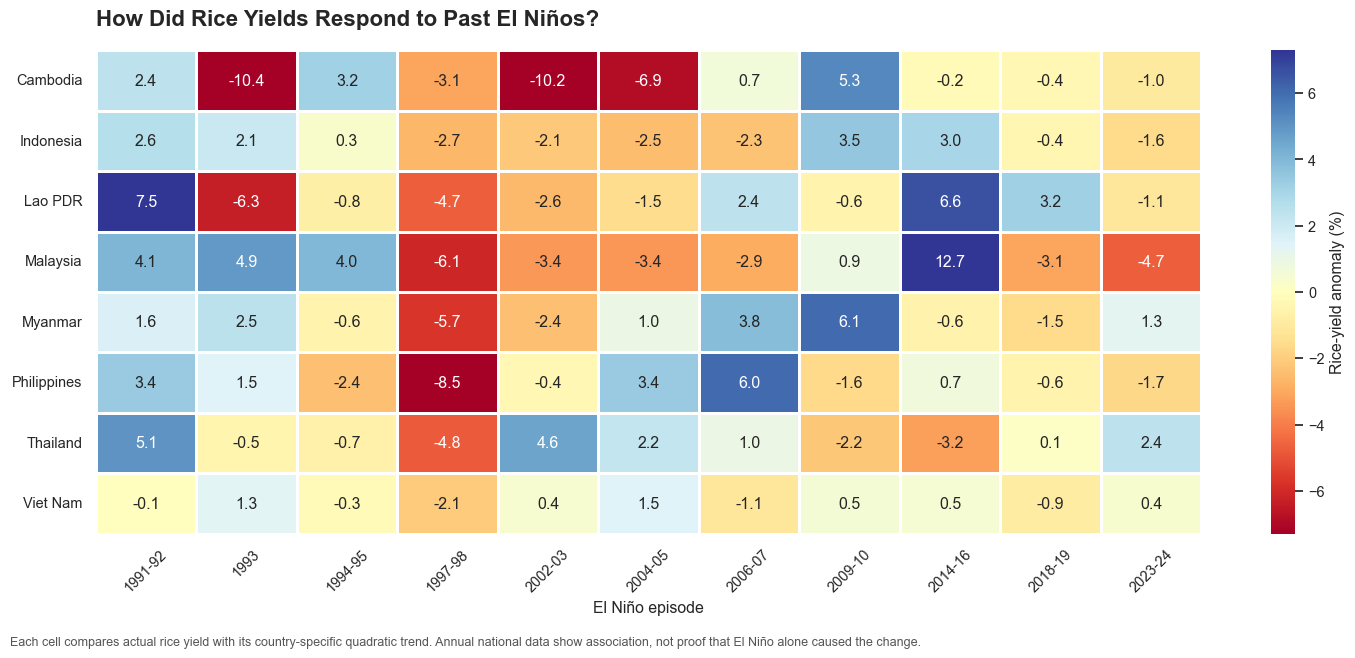

Batas warna simetris: -7.29% sampai +7.29%


In [9]:
values = heatmap_data.to_numpy(dtype=float)
color_limit = float(np.nanpercentile(np.abs(values), 95))

cmap = mpl.colormaps["RdYlBu"].copy()
cmap.set_bad("#D9D9D9")

fig, ax = plt.subplots(figsize=(15, 6.4))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap=cmap,
    center=0,
    vmin=-color_limit,
    vmax=color_limit,
    annot=True,
    fmt=".1f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Rice-yield anomaly (%)"},
)

ax.set_title(
    "How Did Rice Yields Respond to Past El Niños?",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18,
)
ax.set_xlabel("El Niño episode")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
fig.text(
    0.01,
    -0.02,
    "Each cell compares actual rice yield with its country-specific quadratic trend. "
    "Annual national data show association, not proof that El Niño alone caused the change.",
    fontsize=9,
    color="#555555",
)
fig.tight_layout()
plt.show()

print(f"Batas warna simetris: {-color_limit:.2f}% sampai +{color_limit:.2f}%")


## 8. Sensitivity check: kuadratik versus linear

Perbandingan ini memeriksa apakah kesimpulan visual terlalu bergantung pada bentuk tren. `Sign_Flips` menghitung berapa episode yang berubah dari negatif ke positif atau sebaliknya ketika tren kuadratik diganti dengan tren linear.


In [10]:
event_data["Quadratic_vs_Linear_Difference"] = (
    event_data["Event_Anomaly_Quadratic"] - event_data["Event_Anomaly_Linear"]
)
event_data["Quadratic_vs_Linear_Sign_Flip"] = (
    np.sign(event_data["Event_Anomaly_Quadratic"])
    != np.sign(event_data["Event_Anomaly_Linear"])
)

trend_sensitivity = (
    event_data.groupby("Country")
    .agg(
        Mean_Absolute_Difference=("Quadratic_vs_Linear_Difference", lambda s: s.abs().mean()),
        Max_Absolute_Difference=("Quadratic_vs_Linear_Difference", lambda s: s.abs().max()),
        Sign_Flips=("Quadratic_vs_Linear_Sign_Flip", "sum"),
        Episodes=("Episode_Label", "nunique"),
    )
    .reindex(TARGET_COUNTRIES)
)
trend_sensitivity["Sign_Flip_Rate"] = (
    trend_sensitivity["Sign_Flips"] / trend_sensitivity["Episodes"]
)

overall_flip_rate = event_data["Quadratic_vs_Linear_Sign_Flip"].mean()
overall_mean_abs_difference = event_data["Quadratic_vs_Linear_Difference"].abs().mean()
stability_label = "cukup stabil" if overall_flip_rate < 0.10 else "belum sepenuhnya stabil"

display(trend_sensitivity.round(3))
print(f"Overall sign-flip rate: {overall_flip_rate:.1%}")
print(f"Overall mean absolute difference: {overall_mean_abs_difference:.2f} percentage points")
print(f"Kesimpulan sensitivity check: pola heatmap {stability_label} terhadap pilihan tren.")


,Mean_Absolute_Difference,Max_Absolute_Difference,Sign_Flips,Episodes,Sign_Flip_Rate
Country,,,,,
Cambodia,1.751,4.787,2,11,0.182
Indonesia,0.182,0.346,0,11,0.000
Lao PDR,4.480,10.264,4,11,0.364
Malaysia,3.264,6.420,3,11,0.273
Myanmar,3.568,6.845,5,11,0.455
Philippines,0.952,1.967,1,11,0.091
Thailand,5.583,11.144,4,11,0.364
Viet Nam,3.008,6.587,3,11,0.273


Overall sign-flip rate: 25.0%
Overall mean absolute difference: 2.85 percentage points
Kesimpulan sensitivity check: pola heatmap belum sepenuhnya stabil terhadap pilihan tren.


## 9. Sensitivity check: event window, peak year, dan t+1

Jika tanda anomaly berubah antara peak year dan t+1, respons timing negara pada episode tersebut dianggap tidak konsisten. Perbandingan ini penting karena El Niño yang memuncak di akhir tahun dapat memengaruhi panen tahun berikutnya.


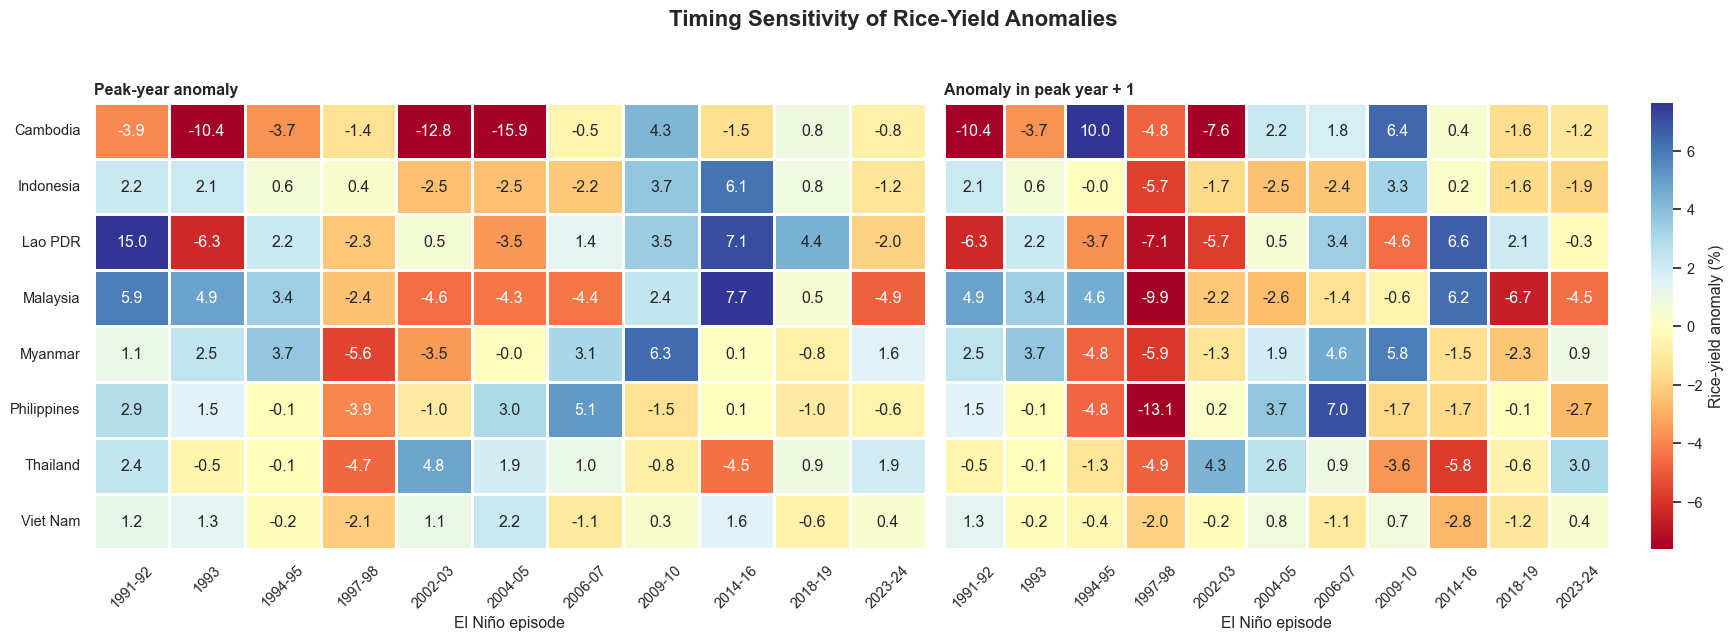

,Peak_vs_T1_Sign_Flips,Comparable_Episodes,Sign_Flip_Rate
Country,,,
Cambodia,5,11,0.455
Indonesia,3,11,0.273
Lao PDR,6,11,0.545
Malaysia,2,11,0.182
Myanmar,3,11,0.273
Philippines,3,11,0.273
Thailand,2,11,0.182
Viet Nam,3,11,0.273


In [11]:
peak_heatmap = (
    event_data.pivot(index="Country", columns="Episode_Label", values="Peak_Year_Anomaly")
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)
t1_heatmap = (
    event_data.pivot(index="Country", columns="Episode_Label", values="T_plus_1_Anomaly")
    .reindex(index=TARGET_COUNTRIES, columns=episode_order)
)

timing_valid = event_data[["Peak_Year_Anomaly", "T_plus_1_Anomaly"]].notna().all(axis=1)
event_data["Peak_vs_T1_Sign_Flip"] = False
event_data.loc[timing_valid, "Peak_vs_T1_Sign_Flip"] = (
    np.sign(event_data.loc[timing_valid, "Peak_Year_Anomaly"])
    != np.sign(event_data.loc[timing_valid, "T_plus_1_Anomaly"])
)

timing_sensitivity = (
    event_data.loc[timing_valid]
    .groupby("Country")
    .agg(
        Peak_vs_T1_Sign_Flips=("Peak_vs_T1_Sign_Flip", "sum"),
        Comparable_Episodes=("Episode_Label", "nunique"),
    )
    .reindex(TARGET_COUNTRIES)
)
timing_sensitivity["Sign_Flip_Rate"] = (
    timing_sensitivity["Peak_vs_T1_Sign_Flips"]
    / timing_sensitivity["Comparable_Episodes"]
)

timing_limit = float(
    np.nanpercentile(
        np.abs(np.concatenate([peak_heatmap.to_numpy().ravel(), t1_heatmap.to_numpy().ravel()])),
        95,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.2), sharey=True)
for ax, matrix, title in [
    (axes[0], peak_heatmap, "Peak-year anomaly"),
    (axes[1], t1_heatmap, "Anomaly in peak year + 1"),
]:
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        center=0,
        vmin=-timing_limit,
        vmax=timing_limit,
        annot=True,
        fmt=".1f",
        linewidths=0.8,
        linecolor="white",
        cbar=ax is axes[1],
        cbar_kws={"label": "Rice-yield anomaly (%)"} if ax is axes[1] else None,
    )
    ax.set_title(title, fontweight="bold", loc="left")
    ax.set_xlabel("El Niño episode")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Timing Sensitivity of Rice-Yield Anomalies", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

display(timing_sensitivity.round(3))


## 10. Ringkasan hasil untuk membantu membaca heatmap

Ringkasan di bawah hanya mendeskripsikan pola historis pada data nasional. Ia tidak membuktikan bahwa El Niño merupakan satu-satunya penyebab perubahan yield.


In [12]:
country_summary = (
    event_data.groupby("Country")
    .agg(
        Mean_Event_Anomaly=("Event_Anomaly_Quadratic", "mean"),
        Below_Trend_Episodes=("Event_Anomaly_Quadratic", lambda s: int((s < 0).sum())),
        Episodes_At_or_Below_Minus_5=("Event_Anomaly_Quadratic", lambda s: int((s <= -5).sum())),
        Lowest_Anomaly=("Event_Anomaly_Quadratic", "min"),
    )
    .reindex(TARGET_COUNTRIES)
)

lowest_episode_by_country = (
    event_data.loc[event_data.groupby("Country")["Event_Anomaly_Quadratic"].idxmin(),
                   ["Country", "Episode_Label"]]
    .set_index("Country")["Episode_Label"]
)
country_summary["Lowest_Episode"] = lowest_episode_by_country

episode_summary = (
    event_data.groupby("Episode_Label", sort=False)
    .agg(
        Mean_Across_Countries=("Event_Anomaly_Quadratic", "mean"),
        Countries_Below_Trend=("Event_Anomaly_Quadratic", lambda s: int((s < 0).sum())),
        Minimum_Country_Value=("Event_Anomaly_Quadratic", "min"),
    )
    .reindex(episode_order)
)

display(country_summary.round(2))
display(episode_summary.round(2))

most_negative_episode = episode_summary["Mean_Across_Countries"].idxmin()
most_negative_mean = episode_summary.loc[most_negative_episode, "Mean_Across_Countries"]
most_negative_count = int(episode_summary.loc[most_negative_episode, "Countries_Below_Trend"])

print(
    f"Episode dengan rata-rata regional paling negatif adalah {most_negative_episode}: "
    f"{most_negative_mean:.2f}% dan {most_negative_count} dari {len(TARGET_COUNTRIES)} negara berada di bawah tren."
)
print(
    "Interpretasi aman: sel merah yang berulang menunjukkan negara yang lebih sering mencatat yield di bawah tren "
    "selama episode historis, bukan bukti bahwa RONI sendirian menyebabkan perubahan tersebut."
)


,Mean_Event_Anomaly,Below_Trend_Episodes,Episodes_At_or_Below_Minus_5,Lowest_Anomaly,Lowest_Episode
Country,,,,,
Cambodia,-1.87,7,3,-10.38,1993
Indonesia,-0.01,6,0,-2.66,1997-98
Lao PDR,0.19,7,1,-6.33,1993
Malaysia,0.26,6,1,-6.13,1997-98
Myanmar,0.50,5,1,-5.72,1997-98
Philippines,-0.02,6,1,-8.54,1997-98
Thailand,0.36,5,0,-4.80,1997-98
Viet Nam,0.02,5,0,-2.07,1997-98


,Mean_Across_Countries,Countries_Below_Trend,Minimum_Country_Value
Episode_Label,,,
1991-92,3.33,1,-0.05
1993,-0.62,3,-10.38
1994-95,0.34,5,-2.43
1997-98,-4.71,8,-8.54
2002-03,-2.02,6,-10.21
2004-05,-0.79,4,-6.87
2006-07,0.95,3,-2.91
2009-10,1.50,3,-2.21
2014-16,2.44,3,-3.23


Episode dengan rata-rata regional paling negatif adalah 1997-98: -4.71% dan 8 dari 8 negara berada di bawah tren.
Interpretasi aman: sel merah yang berulang menunjukkan negara yang lebih sering mencatat yield di bawah tren selama episode historis, bukan bukti bahwa RONI sendirian menyebabkan perubahan tersebut.


## Kesimpulan metode

- Heatmap memakai **yield anomaly**, bukan yield mentah.
- Expected yield utama berasal dari **tren kuadratik per negara**.
- Episode ditentukan langsung dari RONI, bukan daftar tahun manual.
- Satu episode menjadi satu kolom, dan episode lintas tahun diringkas dengan rata-rata anomaly tahunan.
- Skala warna dibuat simetris terhadap nol.
- Tren linear, peak year, dan t+1 dipakai untuk mengecek kestabilan hasil.
- Data tahunan nasional menunjukkan asosiasi historis, bukan kausalitas tunggal.


# STACKED BAR TRADE RICE

Jumlah record: 69
reporterDesc
M    [HS]
Name: classificationCode, dtype: object
reporterDesc
M    [31285681.0, 119120.0, 3000.0, 9009000.0, 1340...
Name: qtyUnitAbbr, dtype: object
Empty DataFrame
Columns: [reporterDesc, world_netWgt, partner_sum, gap_pct]
Index: []
Empty DataFrame
Columns: [HHI, supplier_count, import_kg, HHI_10000, effective_suppliers, interpretation]
Index: []


C:\Users\ACER\AppData\Local\Temp\ipykernel_69472\2548490213.py:298: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


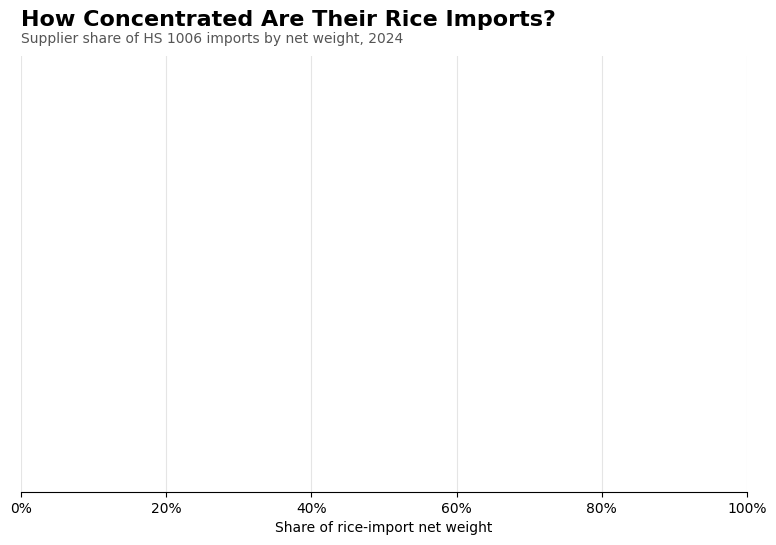

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# =========================================================
# 1. Ambil data UN Comtrade
# =========================================================


raw = pd.read_csv("TradeData_8_27_2026_21_50_21.csv")

print("Jumlah record:", len(raw))

if len(raw) >= 500:
    print("Peringatan: hasil mencapai batas preview API.")

# =========================================================
# 2. Periksa klasifikasi dan satuan
# =========================================================

print(
    raw.groupby("reporterDesc")["classificationCode"]
       .unique()
)

print(
    raw.groupby("reporterDesc")["qtyUnitAbbr"]
       .unique()
)

# =========================================================
# 3. Pisahkan World total dan data partner
# =========================================================

world = (
    raw.loc[raw["partnerCode"] == 0,
            ["reporterDesc", "netWgt"]]
       .rename(columns={"netWgt": "world_netWgt"})
)

partners = raw.loc[
    (raw["partnerCode"] != 0) &
    (raw["netWgt"].notna()) &
    (raw["netWgt"] > 0)
].copy()

# Jika ada lebih dari satu baris untuk pasangan yang sama,
# jumlahkan dahulu.
partners = (
    partners
    .groupby(
        ["reporterDesc", "partnerDesc"],
        as_index=False
    )
    .agg(
        netWgt=("netWgt", "sum"),
        estimated=("isNetWgtEstimated", "max")
    )
)

# =========================================================
# 4. Quality check terhadap World total
# =========================================================

partner_total = (
    partners
    .groupby("reporterDesc", as_index=False)["netWgt"]
    .sum()
    .rename(columns={"netWgt": "partner_sum"})
)

quality_check = world.merge(
    partner_total,
    on="reporterDesc",
    how="outer"
)

quality_check["gap_pct"] = (
    abs(
        quality_check["partner_sum"] -
        quality_check["world_netWgt"]
    )
    / quality_check["world_netWgt"]
    * 100
)

print(quality_check)

# =========================================================
# 5. Hitung supplier share
# =========================================================

partners["share"] = (
    partners["netWgt"] /
    partners.groupby("reporterDesc")["netWgt"]
            .transform("sum")
)

partners["share_pct"] = partners["share"] * 100

# =========================================================
# 6. Hitung HHI dari semua pemasok
# =========================================================

hhi = (
    partners
    .assign(share_squared=lambda x: x["share"] ** 2)
    .groupby("reporterDesc")
    .agg(
        HHI=("share_squared", "sum"),
        supplier_count=("partnerDesc", "nunique"),
        import_kg=("netWgt", "sum")
    )
)

hhi["HHI_10000"] = hhi["HHI"] * 10000
hhi["effective_suppliers"] = 1 / hhi["HHI"]

def interpret_hhi(value):
    if value < 1000:
        return "Low concentration: more supplier options"
    elif value <= 1800:
        return "Moderate concentration"
    else:
        return "High concentration: fewer alternatives"

hhi["interpretation"] = (
    hhi["HHI_10000"].apply(interpret_hhi)
)

print(
    hhi.sort_values(
        "HHI_10000",
        ascending=False
    )
)

# =========================================================
# 7. Gabungkan pemasok kecil untuk visual saja
# =========================================================

# Pertahankan pemasok yang mencapai minimal 3%
# di setidaknya satu negara.
max_share = (
    partners.groupby("partnerDesc")["share"]
            .max()
)

major_suppliers = max_share[
    max_share >= 0.03
].index

partners["supplier_plot"] = np.where(
    partners["partnerDesc"].isin(major_suppliers),
    partners["partnerDesc"],
    "Other"
)

plot_long = (
    partners
    .groupby(
        ["reporterDesc", "supplier_plot"],
        as_index=False
    )["share_pct"]
    .sum()
)

plot_data = (
    plot_long
    .pivot(
        index="reporterDesc",
        columns="supplier_plot",
        values="share_pct"
    )
    .fillna(0)
)

# Urutkan negara berdasarkan HHI tertinggi.
country_order = (
    hhi.sort_values(
        "HHI_10000",
        ascending=False
    )
    .index
    .tolist()
)

plot_data = plot_data.reindex(country_order)

preferred_order = [
    "Viet Nam",
    "Thailand",
    "India",
    "Pakistan",
    "Cambodia",
    "Myanmar",
    "Other"
]

supplier_order = [
    supplier for supplier in preferred_order
    if supplier in plot_data.columns
]

plot_data = plot_data[supplier_order]

# =========================================================
# 8. Buat 100% stacked bar
# =========================================================

colors = {
    "Viet Nam": "#0072B2",
    "Thailand": "#E69F00",
    "India": "#009E73",
    "Pakistan": "#CC79A7",
    "Cambodia": "#56B4E9",
    "Myanmar": "#D55E00",
    "Other": "#C9C9C9"
}

fig, ax = plt.subplots(figsize=(12, 6.5))

y = np.arange(len(plot_data))
left = np.zeros(len(plot_data))

for supplier in supplier_order:
    values = plot_data[supplier].to_numpy()

    bars = ax.barh(
        y,
        values,
        left=left,
        label=supplier,
        color=colors[supplier],
        height=0.68
    )

    # Tampilkan label hanya untuk segmen yang cukup besar.
    for index, value in enumerate(values):
        if value >= 5:
            ax.text(
                left[index] + value / 2,
                index,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold"
            )

    left += values

# Tambahkan nilai HHI di sebelah kanan batang.
for index, country in enumerate(plot_data.index):
    hhi_value = hhi.loc[country, "HHI_10000"]
    interpretation = hhi.loc[country, "interpretation"]

    ax.text(
        1.02,
        index,
        f"HHI {hhi_value:,.0f}\n{interpretation}",
        transform=ax.get_yaxis_transform(),
        ha="left",
        va="center",
        fontsize=9
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_data.index)
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.xaxis.set_major_formatter(PercentFormatter(100))

ax.set_xlabel("Share of rice-import net weight")
ax.set_ylabel("")

ax.set_title(
    "How Concentrated Are Their Rice Imports?",
    loc="left",
    fontsize=16,
    fontweight="bold",
    pad=22
)

ax.text(
    0,
    1.03,
    "Supplier share of HS 1006 imports by net weight, 2024",
    transform=ax.transAxes,
    fontsize=10,
    color="#555555"
)

ax.legend(
    ncol=4,
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0, 1.06)
)

ax.grid(
    axis="x",
    color="#E5E5E5",
    linewidth=0.8
)

ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.subplots_adjust(right=0.73, top=0.78)
plt.savefig(
    "rice_import_supplier_concentration_2024.svg",
    bbox_inches="tight"
)
plt.savefig(
    "rice_import_supplier_concentration_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()